In [368]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [369]:
data = pd.read_csv('..\dataset\patient_data.csv')

In [370]:
data.isnull().sum()

C                  0
Age                0
History            0
Patient            0
TakeMedication     0
Severity           0
BreathShortness    0
VisualChanges      0
NoseBleeding       0
Whendiagnoused     0
Systolic           0
Diastolic          0
ControlledDiet     0
Stages             0
dtype: int64

In [371]:
data.rename(columns={'C':"Gender"},inplace=True)

In [372]:
data['TakeMedication'].replace({'Yes ':'Yes'},inplace=True)
data['NoseBleeding'].replace({'No ':'No'},inplace=True)
data['Systolic'].replace({'121- 130':'121 - 130'},inplace=True)
data['Systolic'].replace({'100+':'100 - 110'},inplace=True)
data['Stages'].replace({'HYPERTENSION (Stage-2).':'HYPERTENSION (Stage-2)'},inplace=True)
data['Stages'].replace({'HYPERTENSIVE CRISI':'HYPERTENSIVE CRISIS'},inplace=True)

print((data['Diastolic'] == '130+').sum())
print((data['Diastolic'] == '100+').sum())

data['Diastolic'].replace({'130+':'100+'},inplace=True)

4
237


C:\RTemp\ipykernel_48864\1114696583.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['TakeMedication'].replace({'Yes ':'Yes'},inplace=True)
C:\RTemp\ipykernel_48864\1114696583.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value,

In [373]:
print(data.duplicated().sum())

data.drop_duplicates(inplace=True)


477


In [374]:
nominal_features=['Gender', 'History', 'Patient', 'TakeMedication', 'BreathShortness', 'VisualChanges', 'NoseBleeding', 'ControlledDiet',]
ordinal_features=[f for f in data.columns if f not in nominal_features]
ordinal_features.remove('Stages')
print(nominal_features)
print(ordinal_features)

['Gender', 'History', 'Patient', 'TakeMedication', 'BreathShortness', 'VisualChanges', 'NoseBleeding', 'ControlledDiet']
['Age', 'Severity', 'Whendiagnoused', 'Systolic', 'Diastolic']


In [375]:
print(data['Severity'].unique())

['Mild' 'Sever' 'Moderate']


In [376]:
for col in nominal_features:
    if set(data[col].unique()) == set(['Yes','No']):
        data[col] = data[col].map({'No':0, 'Yes':1})
    elif col == 'Gender':
        data[col] = data[col].map({'Male':0, 'Female':1})

data['Age'] = data['Age'].map({'18-34':1, '35-50':2, '51-64':3, '65+':4})

data['Severity'] = data['Severity'].map({'Mild':0, 'Moderate':1, 'Sever':2})

data['Whendiagnoused'] = data['Whendiagnoused'].map({'<1 Year':1, '1 - 5 Years':2, '>5 Years':3})

data['Systolic'] = data['Systolic'].map({'100 - 110': 0, '111 - 120': 1, '121 - 130': 2, '130+': 3})

data['Diastolic'] = data['Diastolic'].map({'70 - 80': 0, '81 - 90': 1, '91 - 100': 2, '100+': 3})

data['Stages'] = data['Stages'].map({'NORMAL':0, 'HYPERTENSION (Stage-1)':1, 'HYPERTENSION (Stage-2)':2, 'HYPERTENSIVE CRISIS':3})

In [377]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
data[ordinal_features] = scaler.fit_transform(data[ordinal_features])

# virtual analysis

C:\RTemp\ipykernel_48864\885281450.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x="Gender_label", palette="Set2")


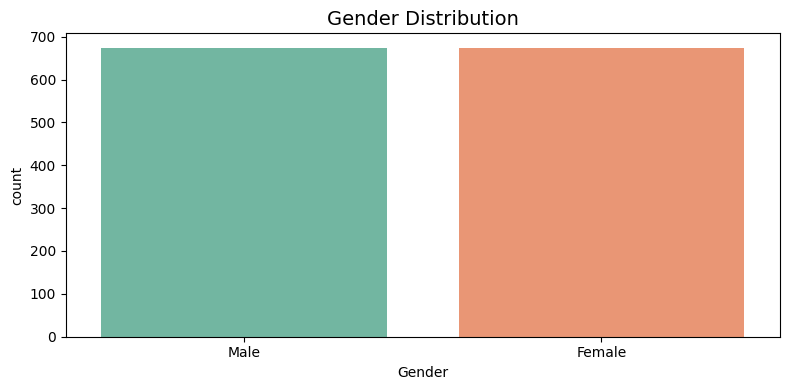

In [378]:
# # Count of each categorical feature

data['Gender_label'] = data['Gender'].map({0: "Male", 1: "Female"})

plt.figure(figsize=(8,4))
sns.countplot(data=data, x="Gender_label", palette="Set2")
plt.title("Gender Distribution", fontsize=14)
plt.xlabel("Gender")
plt.ylabel("count")
plt.tight_layout()
plt.show()

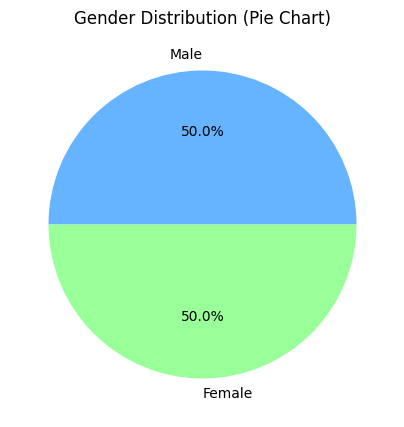

In [379]:
# Pie chart for Gender
data['Gender_label'].value_counts().plot.pie(autopct='%1.1f%%', figsize=(5,5), colors=['#66b3ff','#99ff99'])
plt.title("Gender Distribution (Pie Chart)")
plt.ylabel("")
plt.show()

C:\RTemp\ipykernel_48864\1723770741.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x="Stages_label", palette="coolwarm")


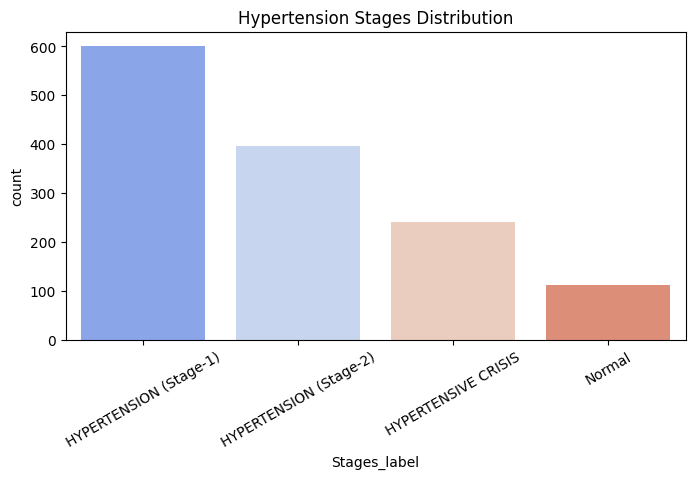

In [380]:
stage_label = {
    0: "Normal",
    1: "HYPERTENSION (Stage-1)",
    2: "HYPERTENSION (Stage-2)",
    3: "HYPERTENSIVE CRISIS"
}

data['Stages_label'] = data['Stages'].map(stage_label)

plt.figure(figsize=(8,4))
sns.countplot(data=data, x="Stages_label", palette="coolwarm")
plt.title("Hypertension Stages Distribution")
plt.xticks(rotation=30)
plt.show()

In [381]:
# Create duplicate string columns ONLY for visualization
data['Systolic_str'] = data['Systolic'].astype(str)
data['Diastolic_str'] = data['Diastolic'].astype(str)

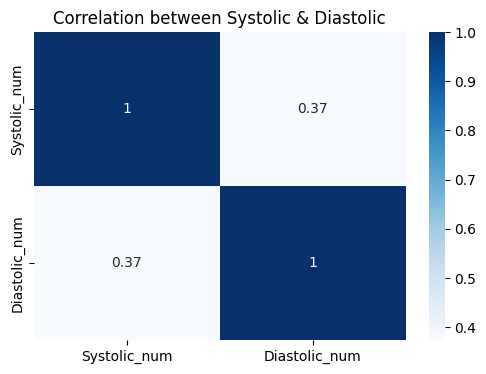

In [382]:
# Heatmap on encoded numeric BP only (after midpoint conversion)

import numpy as np

def range_to_midpoint(val):
    try:
        val = str(val).strip()   # force clean string safely
        
        if "-" in val:
            start, end = val.split("-")
            return (int(start.strip()) + int(end.strip())) / 2
        
        elif "+" in val:
            return int(val.replace("+", "").strip())
        
        else:
            return float(val)   # handles single numeric values like "120"
    
    except:
        return np.nan


# Create numeric columns safely (overwrite allowed)
data['Systolic_num'] = data['Systolic_str'].apply(range_to_midpoint)
data['Diastolic_num'] = data['Diastolic_str'].apply(range_to_midpoint)

plt.figure(figsize=(6,4))
sns.heatmap(data[['Systolic_num', 'Diastolic_num']].corr(), annot=True, cmap="Blues")
plt.title("Correlation between Systolic & Diastolic")
plt.show()

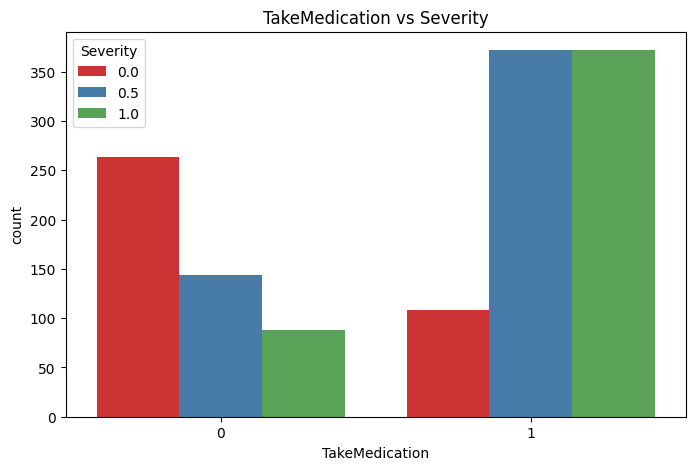

In [383]:
# Relationship: TakeMedication vs Severity
plt.figure(figsize=(8,5))
sns.countplot(data=data, x="TakeMedication", hue="Severity", palette="Set1")
plt.title("TakeMedication vs Severity")
plt.show()

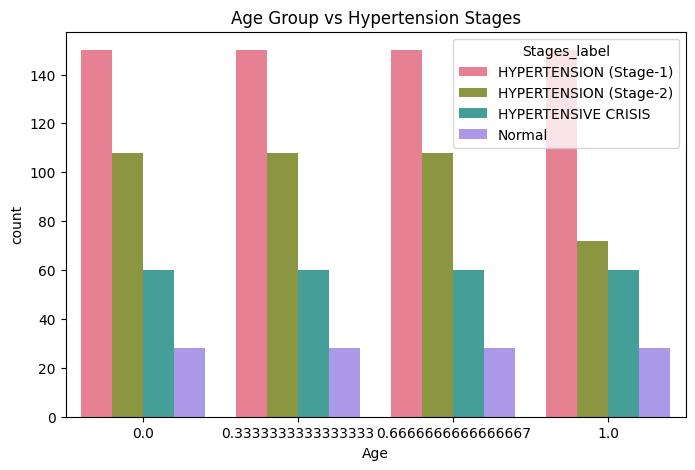

In [384]:
# Age group vs Stages
plt.figure(figsize=(8,5))
sns.countplot(data=data, x="Age", hue="Stages_label", palette="husl")
plt.title("Age Group vs Hypertension Stages")
plt.show()

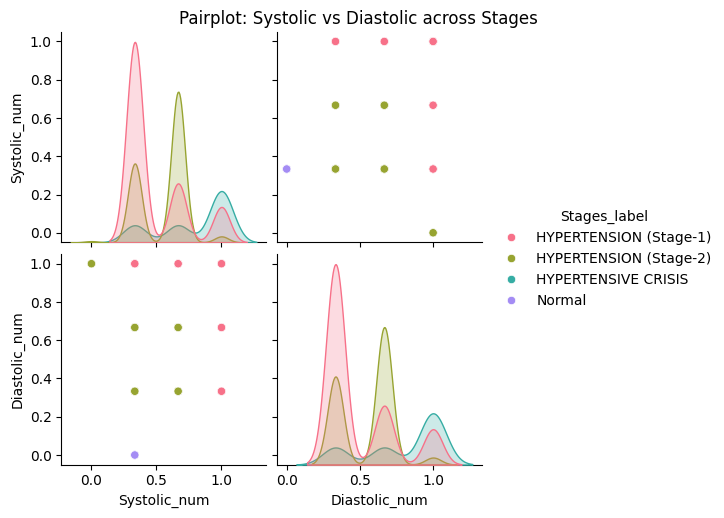

In [385]:
# Pairplot using label column (minimal change)
sns.pairplot(
    data[['Systolic_num','Diastolic_num','Stages_label']].dropna(),
    hue='Stages_label',
    diag_kind='kde',
    palette="husl"
)

plt.suptitle("Pairplot: Systolic vs Diastolic across Stages", y=1.02)
plt.show()

In [386]:
data = data.drop(
    columns=['Systolic_str', 'Diastolic_str', 'Stages_label','Gender_label'],
    errors='ignore'   # prevents error if column not present
)

In [387]:
data = data.drop(
    columns=['Systolic', 'Diastolic'],
    errors='ignore'
)

In [388]:
print(data.dtypes)

Gender               int64
Age                float64
History              int64
Patient              int64
TakeMedication       int64
Severity           float64
BreathShortness      int64
VisualChanges        int64
NoseBleeding         int64
Whendiagnoused     float64
ControlledDiet       int64
Stages               int64
Systolic_num       float64
Diastolic_num      float64
dtype: object


In [389]:
print(data.isnull().sum())

Gender             0
Age                0
History            0
Patient            0
TakeMedication     0
Severity           0
BreathShortness    0
VisualChanges      0
NoseBleeding       0
Whendiagnoused     0
ControlledDiet     0
Stages             0
Systolic_num       0
Diastolic_num      0
dtype: int64


# Data Splitting

In [390]:
from sklearn.model_selection import train_test_split
x = data.drop('Stages', axis=1)
y = data['Stages']
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print("Split Results:\n")
print(f"Training set: {X_train.shape[0]} samples ({round((X_train.shape[0]/len(data))*100)}%)")
print(f"Testing set: {X_test.shape[0]} samples ({round((X_test.shape[0]/len(data))*100)}%)")
print("\nStratified sampling ensures balanced class representation.")

Split Results:

Training set: 1078 samples (80%)
Testing set: 270 samples (20%)

Stratified sampling ensures balanced class representation.


In [391]:
from sklearn.linear_model import LogisticRegression,RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
accuracy={}

# Algorithms

-------
Logistic Regression

In [392]:
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)

print("Logistic Regression:")
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
accuracy['Logistic Regression'] = accuracy_score(y_test, y_pred)

Logistic Regression:
Accuracy: 95.19%
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00       113
           2       1.00      0.85      0.92        85
           3       0.79      1.00      0.88        49

    accuracy                           0.95       270
   macro avg       0.95      0.96      0.95       270
weighted avg       0.96      0.95      0.95       270

Confusion Matrix:
 [[ 23   0   0   0]
 [  0 113   0   0]
 [  0   0  72  13]
 [  0   0   0  49]]


-----
Decision Tree Classifier

In [393]:
decisionTree=DecisionTreeClassifier()
decisionTree.fit(X_train, y_train)
y_pred = decisionTree.predict(X_test)
print("Decision Tree:")
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
accuracy['Decision Tree']=accuracy_score(y_test, y_pred)

Decision Tree:
Accuracy: 100.00%
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00       113
           2       1.00      1.00      1.00        85
           3       1.00      1.00      1.00        49

    accuracy                           1.00       270
   macro avg       1.00      1.00      1.00       270
weighted avg       1.00      1.00      1.00       270

Confusion Matrix:
 [[ 23   0   0   0]
 [  0 113   0   0]
 [  0   0  85   0]
 [  0   0   0  49]]


-----
Random Forest Classifier

In [394]:
randomforest=RandomForestClassifier()
randomforest.fit(X_train, y_train)
y_pred = randomforest.predict(X_test)
print("Random Forest:")
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
accuracy['Random Forest']=accuracy_score(y_test, y_pred)

Random Forest:
Accuracy: 100.00%
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00       113
           2       1.00      1.00      1.00        85
           3       1.00      1.00      1.00        49

    accuracy                           1.00       270
   macro avg       1.00      1.00      1.00       270
weighted avg       1.00      1.00      1.00       270

Confusion Matrix:
 [[ 23   0   0   0]
 [  0 113   0   0]
 [  0   0  85   0]
 [  0   0   0  49]]


------
 Support Vector Machine (SVM)

In [395]:
svm=SVC()
svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)
print("SVM:")
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
accuracy['SVM']=accuracy_score(y_test, y_pred)

SVM:
Accuracy: 100.00%
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00       113
           2       1.00      1.00      1.00        85
           3       1.00      1.00      1.00        49

    accuracy                           1.00       270
   macro avg       1.00      1.00      1.00       270
weighted avg       1.00      1.00      1.00       270

Confusion Matrix:
 [[ 23   0   0   0]
 [  0 113   0   0]
 [  0   0  85   0]
 [  0   0   0  49]]


------
K-Nearest Neighbors (KNN)

In [396]:
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
print("KNN:")
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
accuracy['KNN']=accuracy_score(y_test, y_pred)

KNN:
Accuracy: 98.15%
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.78      0.88        23
           1       0.96      1.00      0.98       113
           2       1.00      1.00      1.00        85
           3       1.00      1.00      1.00        49

    accuracy                           0.98       270
   macro avg       0.99      0.95      0.96       270
weighted avg       0.98      0.98      0.98       270

Confusion Matrix:
 [[ 18   5   0   0]
 [  0 113   0   0]
 [  0   0  85   0]
 [  0   0   0  49]]


------
Ridge Classifier

In [397]:
RC=RidgeClassifier()
RC.fit(X_train, y_train)
y_pred = RC.predict(X_test)
print("RidgeClassifier:")
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
accuracy['Ridge Classifier']=accuracy_score(y_test, y_pred)

RidgeClassifier:
Accuracy: 90.00%
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.57      0.72        23
           1       0.92      1.00      0.96       113
           2       0.93      0.87      0.90        85
           3       0.80      0.88      0.83        49

    accuracy                           0.90       270
   macro avg       0.91      0.83      0.85       270
weighted avg       0.91      0.90      0.90       270

Confusion Matrix:
 [[ 13  10   0   0]
 [  0 113   0   0]
 [  0   0  74  11]
 [  0   0   6  43]]


------
Gaussian Naive Bayes (Selected Model)

In [398]:
naive_bayes=GaussianNB()
naive_bayes.fit(X_train, y_train)
y_pred = naive_bayes.predict(X_test)
print("Naive Bayes:")
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
accuracy['Naive Bayes']=accuracy_score(y_test, y_pred)

Naive Bayes:
Accuracy: 84.44%
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00       113
           2       1.00      0.51      0.67        85
           3       0.54      1.00      0.70        49

    accuracy                           0.84       270
   macro avg       0.88      0.88      0.84       270
weighted avg       0.92      0.84      0.84       270

Confusion Matrix:
 [[ 23   0   0   0]
 [  0 113   0   0]
 [  0   0  43  42]
 [  0   0   0  49]]


In [399]:
print(accuracy)

{'Logistic Regression': 0.9518518518518518, 'Decision Tree': 1.0, 'Random Forest': 1.0, 'SVM': 1.0, 'KNN': 0.9814814814814815, 'Ridge Classifier': 0.9, 'Naive Bayes': 0.8444444444444444}


In [400]:
import pandas as pd

# Required order as per sample
required_order = [
    "Decision Tree",
    "Random Forest",
    "SVM",
    "KNN",
    "Logistic Regression",
    "Ridge Classifier",
    "Naive Bayes"
]

# Create DataFrame
performance = pd.DataFrame({
    "Algorithm": accuracy.keys(),
    "Accuracy": [round(v * 100, 1) for v in accuracy.values()]
})

# Reorder rows to match sample
performance = performance.set_index("Algorithm").loc[required_order].reset_index()

# Add % symbol
performance["Accuracy"] = performance["Accuracy"].astype(str) + "%"

# -------- Generalization Assessment --------
def assess(acc):
    acc = float(acc.replace("%", ""))
    
    if acc == 100:
        return "Overfitted"
    elif acc >= 95:
        return "Excellent"
    else:
        return "Good"

performance["Generalization Assessment"] = performance["Accuracy"].apply(assess)

# -------- Selection Status (Only Logistic Selected) --------
def selection(row):
    if row["Algorithm"] == "Logistic Regression":
        return "✅ Selected"
    elif row["Generalization Assessment"] == "Overfitted":
        return "❌ Rejected"
    else:
        return "⚠ Considered"

performance["Selection Status"] = performance.apply(selection, axis=1)

print("\nPerformance Summary:\n")

# Hide index
display(performance.style.hide(axis="index"))


Performance Summary:



Algorithm,Accuracy,Generalization Assessment,Selection Status
Decision Tree,100.0%,Overfitted,❌ Rejected
Random Forest,100.0%,Overfitted,❌ Rejected
SVM,100.0%,Overfitted,❌ Rejected
KNN,98.1%,Excellent,⚠ Considered
Logistic Regression,95.2%,Excellent,✅ Selected
Ridge Classifier,90.0%,Good,⚠ Considered
Naive Bayes,84.4%,Good,⚠ Considered


In [401]:
import joblib

# save model
joblib.dump(logreg, "logreg_model.pkl")
print("✅ Model saved as logreg_model.pkl")

✅ Model saved as logreg_model.pkl
